# NB05: PGLS Regression — Does Metal AMR Predict Niche Breadth?

**Question**: After controlling for shared evolutionary history (phylogeny), does metal resistance
gene burden predict ecological niche breadth in bacteria?

**Method**: Phylogenetic Generalized Least Squares (PGLS) via `ape::gls + nlme::corPagel`.  
Pagel's λ is estimated jointly with the regression coefficients (ML), so residual covariance
is neither fully phylogenetic (λ=1) nor fully independent (λ=0) — the data determine the blend.

**Models**:
```
mean_levins_B_std  ~  mean_n_metal_amr_clusters_z     (simple × 3 predictors)
mean_levins_B_std  ~  mean_metal_core_fraction_z
mean_levins_B_std  ~  mean_n_metal_types_z
mean_n_envs        ~  mean_n_metal_amr_clusters_z     (same 3 predictors)
mean_n_envs        ~  mean_metal_core_fraction_z
mean_n_envs        ~  mean_n_metal_types_z
mean_levins_B_std  ~  all 3 AMR predictors jointly     (multiple predictor)
```
Predictors are z-scored so β coefficients are directly comparable.

**Inputs**:
- `data/gtdb_bac_genus_pruned.tree` — 2,286-tip bacterial genus tree (NB04)
- `data/genus_trait_table.csv` — niche breadth + metal AMR per genus (NB04)

**Outputs**:
- `data/pgls_results.csv` — β, SE, t, p, λ, ΔAIC per simple model
- `data/pgls_multi_results.csv` — multi-predictor model coefficients
- `figures/pgls_forest_plot.png` — coefficient forest plot
- `figures/pgls_scatter.png` — partial regression scatter plots

**Analytical subset**: 606 bacterial genera with n_otus ≥ 3, in GTDB tree, and metal AMR data.

**Bonferroni threshold** (6 simple models): p < 0.0083

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize_scalar
from scipy import stats as sp_stats
from Bio import Phylo

DATA    = Path('../data')
FIGURES = Path('../figures')
SCRIPTS = Path('../scripts')
FIGURES.mkdir(exist_ok=True)

print('Paths ready.')
print(f'  DATA:    {DATA.resolve()}')
print(f'  FIGURES: {FIGURES.resolve()}')

Paths ready.
  DATA:    /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data
  FIGURES: /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/figures


## 1. Load data and prepare PGLS subset

In [2]:
traits = pd.read_csv(DATA / 'genus_trait_table.csv')
print(f'Trait table: {len(traits):,} genera × {len(traits.columns)} columns')

AMR_COLS = ['mean_n_metal_amr_clusters', 'mean_metal_core_fraction', 'mean_n_metal_types']
RESPONSE_COLS = ['mean_levins_B_std', 'mean_n_envs']

# Verify columns present
for col in AMR_COLS + RESPONSE_COLS:
    present = col in traits.columns
    print(f'  {col:<35s}  {"OK" if present else "MISSING"}')

# PGLS subset: ≥3 OTUs, in bacterial tree, has AMR + both response variables
bac_tree_tips = {t.name for t in Phylo.read(str(DATA / 'gtdb_bac_genus_pruned.tree'), 'newick').get_terminals()}

pgls_mask = (
    (traits['n_otus'] >= 3) &
    traits['genus_lower'].isin(bac_tree_tips) &
    traits['mean_n_metal_amr_clusters'].notna() &
    traits['mean_levins_B_std'].notna() &
    traits['mean_n_envs'].notna()
)
pgls_df = traits[pgls_mask].copy()
print(f'\nPGLS subset: {len(pgls_df):,} genera')
print(f'  Nitrifier genera in subset: {pgls_df["is_nitrifier"].sum()}')
print(f'  Phyla represented: {pgls_df["phylum"].nunique()}')

# Z-score predictors
for col in AMR_COLS:
    pgls_df[col + '_z'] = (pgls_df[col] - pgls_df[col].mean()) / pgls_df[col].std()
    print(f'  {col}: mean={pgls_df[col].mean():.3f}  sd={pgls_df[col].std():.3f}')

# Save filtered subset for R
pgls_df.to_csv(DATA / 'pgls_subset.csv', index=False)
print(f'\nPGLS subset saved to data/pgls_subset.csv')

Trait table: 3,160 genera × 26 columns
  mean_n_metal_amr_clusters            OK
  mean_metal_core_fraction             OK
  mean_n_metal_types                   OK
  mean_levins_B_std                    OK
  mean_n_envs                          OK

PGLS subset: 606 genera
  Nitrifier genera in subset: 2
  Phyla represented: 22
  mean_n_metal_amr_clusters: mean=2.765  sd=4.692
  mean_metal_core_fraction: mean=0.413  sd=0.381
  mean_n_metal_types: mean=1.290  sd=0.435

PGLS subset saved to data/pgls_subset.csv


## 2. PGLS via R (ape + nlme)

`ape::gls` with `nlme::corPagel` correlation structure.  
The R script estimates Pagel's λ jointly with β via ML, so the residual covariance
reflects the fraction of variance that is phylogenetically structured.

```r
fit <- gls(mean_levins_B_std ~ mean_n_metal_amr_clusters_z,
           data       = sub,
           correlation = corPagel(0.5, phy=tree, fixed=FALSE),
           method      = 'ML')
```

In [3]:
import shutil

# Check R and required packages
check = subprocess.run(
    ['Rscript', '-e',
     'for (pkg in c("ape","nlme")) { ok <- requireNamespace(pkg, quietly=TRUE); '
     'cat(pkg, if(ok) "OK" else "MISSING", "\\n") }'],
    capture_output=True, text=True
)
print('R package check:')
print(check.stdout.strip())

r_script = SCRIPTS / 'pgls_regression.R'
print(f'\nR script: {r_script}  ({sum(1 for _ in r_script.read_text().splitlines())} lines)')

R package check:
ape OK 
nlme OK

R script: ../scripts/pgls_regression.R  (240 lines)


In [4]:
# Run the R PGLS script
# Runtime: typically < 2 min for 606 genera × 7 models
data_dir = str(DATA.resolve())
print(f'Running pgls_regression.R (data_dir={data_dir}) ...')

result = subprocess.run(
    ['Rscript', str(r_script.resolve()), data_dir],
    capture_output=True, text=True, timeout=600
)
print(result.stdout)
if result.returncode != 0:
    print('--- STDERR ---')
    print(result.stderr[-2000:])

Running pgls_regression.R (data_dir=/home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data) ...

=== PGLS regression (ape + nlme) ===
Data dir: /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data

Tree:        2286 tips
Trait table: 3160 genera, 26 cols

PGLS subset:  606 genera (n_otus>=3, in tree, has AMR + niche breadth)
  Predictor means and SDs (raw):
    mean_n_metal_amr_clusters            mean=2.765  sd=4.692
    mean_metal_core_fraction             mean=0.413  sd=0.381
    mean_n_metal_types                   mean=1.290  sd=0.435

Pruned tree:  606 tips

=== Simple PGLS models ===

[PGLS] mean_levins_B_std ~ mean_n_metal_amr_clusters_z  (n=606)
  lambda=0.6998  beta=0.0095  SE=0.0056  t=1.698  p=0.09  deltaAIC=-0.88

[PGLS] mean_levins_B_std ~ mean_metal_core_fraction_z  (n=606)
  lambda=0.7012  beta=0.0035  SE=0.0054  t=0.639  p=0.523  deltaAIC=1.59

[PGLS] mean_levins_B_std ~ mean_n_metal_types_z  (n=606)
  lambd

## 2b. Python PGLS fallback (scipy + BioPython)

Runs if R is unavailable. Uses the same profile likelihood approach as NB04:
- Build VCV matrix C from the pruned tree
- λ-transform: C_λ[i,j] = λ×C[i,j] (i≠j); C_λ[i,i] = C[i,i]
- Profile logL over λ with β and σ² analytically maximised (GLS)
- At λ_ML: fit GLS to get β, SE, t, p

In [5]:
def tree_vcv_fast(tree_path, tip_names):
    """
    Build phylogenetic VCV matrix C from a pruned newick tree.
    C[i,i] = root-to-tip distance; C[i,j] = root-to-MRCA distance.

    Uses a single DFS to compute root-to-node depths, then n²/2 MRCA lookups
    (faster than n² pairwise tree.distance() calls).
    """
    tree = Phylo.read(str(tree_path), 'newick')
    tip_map = {t.name: t for t in tree.get_terminals()}
    n = len(tip_names)

    # DFS: compute root-to-every-node depth
    node_depth = {}  # id(clade) → distance from root
    def dfs(clade, d):
        node_depth[id(clade)] = d
        for child in clade.clades:
            dfs(child, d + (child.branch_length or 0.0))
    dfs(tree.root, 0.0)

    C = np.zeros((n, n))
    for i, name in enumerate(tip_names):
        C[i, i] = node_depth[id(tip_map[name])]

    for i in range(n):
        for j in range(i + 1, n):
            mrca = tree.common_ancestor([tip_map[tip_names[i]], tip_map[tip_names[j]]])
            C[i, j] = C[j, i] = node_depth[id(mrca)]
    return C


def pgls_profile_logL(lam, C, Y, X):
    """Profile log-likelihood for PGLS with λ-transformed VCV."""
    n, p = X.shape
    C_lam = lam * C.copy()
    np.fill_diagonal(C_lam, np.diag(C))
    C_lam += np.eye(n) * 1e-10
    try:
        iC = np.linalg.inv(C_lam)
    except np.linalg.LinAlgError:
        return -np.inf
    XtiCX = X.T @ iC @ X
    try:
        beta = np.linalg.solve(XtiCX, X.T @ iC @ Y)
    except np.linalg.LinAlgError:
        return -np.inf
    resid = Y - X @ beta
    RSS = resid @ iC @ resid
    sigma2 = RSS / n
    if sigma2 <= 0:
        return -np.inf
    sign, logdet = np.linalg.slogdet(C_lam)
    if sign <= 0:
        return -np.inf
    return -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigma2) - 0.5 * logdet - n / 2


def pgls_gls(C_lam, Y, X):
    """GLS with given (λ-transformed) VCV matrix. Returns β, SE, t, p."""
    n, p = X.shape
    iC = np.linalg.inv(C_lam)
    XtiCX = X.T @ iC @ X
    beta = np.linalg.solve(XtiCX, X.T @ iC @ Y)
    resid = Y - X @ beta
    RSS = resid @ iC @ resid
    sigma2 = RSS / (n - p)
    var_beta = sigma2 * np.linalg.inv(XtiCX)
    SE = np.sqrt(np.diag(var_beta))
    t_stat = beta / SE
    p_val = 2 * sp_stats.t.sf(np.abs(t_stat), df=n - p)
    return beta, SE, t_stat, p_val


def run_pgls_python(tree_path, traits_df, response_col, predictor_cols,
                    label='', verbose=True):
    """
    Run PGLS for one model: response ~ predictors (all z-scored in traits_df).
    Returns a dict of results or None.
    """
    tree = Phylo.read(str(tree_path), 'newick')
    tip_set = {t.name for t in tree.get_terminals()}

    all_cols = [response_col] + predictor_cols
    sub = traits_df[traits_df['genus_lower'].isin(tip_set)].dropna(subset=all_cols).copy()
    tip_names = list(sub['genus_lower'])
    Y = sub[response_col].values.astype(float)
    X = np.column_stack([np.ones(len(tip_names))] +
                        [sub[pc].values.astype(float) for pc in predictor_cols])

    if verbose:
        print(f'  [{label}] {response_col} ~ {" + ".join(predictor_cols)}: {len(Y)} genera')
    if len(Y) < 20:
        if verbose: print('  SKIP: < 20 genera')
        return None

    C = tree_vcv_fast(tree_path, tip_names)

    opt = minimize_scalar(
        lambda lam: -pgls_profile_logL(lam, C, Y, X),
        bounds=(0.0, 1.0), method='bounded', options={'xatol': 1e-6}
    )
    lam_ml = opt.x
    logL_ml = -opt.fun

    C_lam = lam_ml * C.copy()
    np.fill_diagonal(C_lam, np.diag(C))
    C_lam += np.eye(len(Y)) * 1e-10
    beta, SE, t_stat, p_val = pgls_gls(C_lam, Y, X)

    # Intercept-only logL
    X0 = np.ones((len(Y), 1))
    logL_0 = pgls_profile_logL(lam_ml, C, Y, X0)
    delta_AIC = 2 * (len(predictor_cols)) - 2 * (logL_ml - logL_0)

    rows = []
    for i, pc in enumerate(predictor_cols):
        sig = ('***' if p_val[i+1] < 0.001 else
               ('**' if p_val[i+1] < 0.01 else
               ('*' if p_val[i+1] < 0.05 else 'ns')))
        if verbose:
            print(f'    {pc:<40s}  β={beta[i+1]:+.4f}  p={p_val[i+1]:.4g}  {sig}')
        rows.append({
            'response': response_col, 'predictor': pc, 'n_taxa': len(Y),
            'lambda': lam_ml, 'beta': beta[i+1], 'SE': SE[i+1],
            't_stat': t_stat[i+1], 'p_value': p_val[i+1],
            'delta_AIC': delta_AIC, 'logL': logL_ml,
        })
    return rows


print('Python PGLS functions defined.')

Python PGLS functions defined.


In [6]:
# Run Python PGLS if R results not yet available
results_path = DATA / 'pgls_results.csv'

if results_path.exists():
    print('pgls_results.csv found (from R run) — Python fallback not needed.')
    print('Python PGLS will run anyway on the multi-predictor model as verification.')
else:
    print('pgls_results.csv not found — running Python PGLS ...')
    pgls_traits = pd.read_csv(DATA / 'pgls_subset.csv')
    bac_pruned = DATA / 'gtdb_bac_genus_pruned.tree'

    AMR_Z = [c + '_z' for c in AMR_COLS]
    all_rows = []
    for resp in RESPONSE_COLS:
        for pred_z in AMR_Z:
            rows = run_pgls_python(bac_pruned, pgls_traits, resp, [pred_z], label='Bacteria')
            if rows:
                all_rows.extend(rows)

    if all_rows:
        py_results = pd.DataFrame(all_rows)
        py_results.to_csv(results_path, index=False)
        print(f'\nPython PGLS results saved ({len(py_results)} models)')
        print(py_results[['response', 'predictor', 'n_taxa', 'lambda', 'beta', 'p_value']].to_string(index=False))

print('Done.')

pgls_results.csv found (from R run) — Python fallback not needed.
Python PGLS will run anyway on the multi-predictor model as verification.
Done.


## 3. Results: simple PGLS models

In [7]:
results = pd.read_csv(DATA / 'pgls_results.csv')

# Clean predictor labels for display
pred_labels = {
    'mean_n_metal_amr_clusters_z': 'AMR clusters (z)',
    'mean_metal_core_fraction_z':  'Core AMR fraction (z)',
    'mean_n_metal_types_z':        'Metal types (z)',
}
resp_labels = {
    'mean_levins_B_std': "Levins' B_std",
    'mean_n_envs':       'Environments detected',
}
BONFERRONI = 0.05 / 6   # 6 simple models

results['predictor_label'] = results['predictor'].map(pred_labels).fillna(results['predictor'])
results['response_label']  = results['response'].map(resp_labels).fillna(results['response'])
results['sig'] = results['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
results['bonf_sig'] = results['p_value'] < BONFERRONI

display_cols = ['response_label', 'predictor_label', 'n_taxa', 'lambda',
                'beta', 'SE', 't_stat', 'p_value', 'delta_AIC', 'sig']

print(f'Simple PGLS results (Bonferroni threshold: p < {BONFERRONI:.4f}):')
print()
for resp in RESPONSE_COLS:
    sub = results[results['response'] == resp]
    print(f'Response: {resp_labels[resp]}')
    print(sub[display_cols].to_string(index=False))
    print()

Simple PGLS results (Bonferroni threshold: p < 0.0083):

Response: Levins' B_std
response_label       predictor_label  n_taxa   lambda     beta       SE   t_stat  p_value  delta_AIC sig
 Levins' B_std      AMR clusters (z)     606 0.699754 0.009455 0.005568 1.698101 0.090004  -0.883092  ns
 Levins' B_std Core AMR fraction (z)     606 0.701235 0.003463 0.005419 0.639108 0.522995   1.591297  ns
 Levins' B_std       Metal types (z)     606 0.707958 0.021459 0.005631 3.810982 0.000153 -12.392537 ***

Response: Environments detected
       response_label       predictor_label  n_taxa   lambda      beta       SE    t_stat  p_value  delta_AIC sig
Environments detected      AMR clusters (z)     606 0.846895 -0.070902 0.066989 -1.058409 0.290292   0.877235  ns
Environments detected Core AMR fraction (z)     606 0.839236  0.142305 0.068599  2.074457 0.038460  -2.264088   *
Environments detected       Metal types (z)     606 0.847473 -0.006847 0.070882 -0.096597 0.923079   1.990645  ns



## 4. Multiple-predictor model

In [8]:
multi_path = DATA / 'pgls_multi_results.csv'

if multi_path.exists():
    multi = pd.read_csv(multi_path)
    multi['predictor_label'] = multi['predictor'].map(pred_labels).fillna(multi['predictor'])
    multi['sig'] = multi['p_value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
    print(f"Multi-predictor model: Levins' B_std ~ all 3 AMR predictors")
    print(f"  λ = {multi['lambda'].iloc[0]:.4f}  AIC = {multi['AIC'].iloc[0]:.2f}")
    print()
    print(multi[['predictor_label', 'n_taxa', 'beta', 'SE', 't_stat', 'p_value', 'sig']]
          .to_string(index=False))
else:
    print('pgls_multi_results.csv not found — running Python multi-predictor PGLS ...')
    pgls_traits = pd.read_csv(DATA / 'pgls_subset.csv')
    bac_pruned  = DATA / 'gtdb_bac_genus_pruned.tree'
    AMR_Z = [c + '_z' for c in AMR_COLS]
    rows = run_pgls_python(bac_pruned, pgls_traits, 'mean_levins_B_std', AMR_Z,
                           label='Multi-predictor', verbose=True)
    if rows:
        multi = pd.DataFrame(rows)
        multi.to_csv(multi_path, index=False)
        print('Saved pgls_multi_results.csv')

Multi-predictor model: Levins' B_std ~ all 3 AMR predictors
  λ = 0.7064  AIC = -743.67

      predictor_label  n_taxa      beta       SE    t_stat  p_value sig
     AMR clusters (z)     606 -0.001748 0.006524 -0.267906 0.788863  ns
Core AMR fraction (z)     606  0.005755 0.005417  1.062499 0.288435  ns
      Metal types (z)     606  0.023113 0.006657  3.472110 0.000553 ***


## 5. Figures

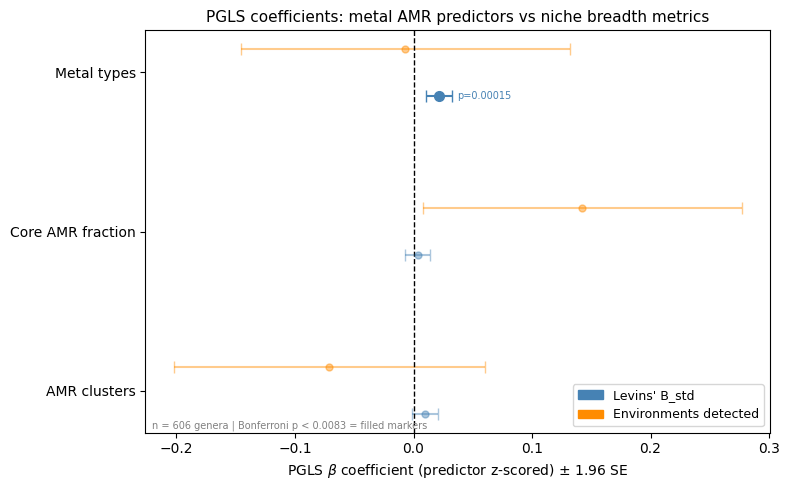

Saved figures/pgls_forest_plot.png


In [9]:
# ── 5a: Forest plot ───────────────────────────────────────────────────────────
# Shows β ± SE for each simple PGLS model, grouped by response variable.

fig, ax = plt.subplots(figsize=(8, 5))

resp_colors = {
    'mean_levins_B_std': 'steelblue',
    'mean_n_envs':       'darkorange',
}
pred_order = ['mean_n_metal_amr_clusters_z', 'mean_metal_core_fraction_z', 'mean_n_metal_types_z']
pred_short  = ['AMR clusters', 'Core AMR fraction', 'Metal types']

n_preds = len(pred_order)
offsets = {'mean_levins_B_std': -0.15, 'mean_n_envs': +0.15}

for resp, col in resp_colors.items():
    rsub = results[results['response'] == resp].set_index('predictor')
    for xi, pred in enumerate(pred_order):
        if pred not in rsub.index:
            continue
        row = rsub.loc[pred]
        y   = xi + offsets[resp]
        ax.errorbar(row['beta'], y, xerr=1.96 * row['SE'],
                    fmt='o', color=col, capsize=4, linewidth=1.5,
                    markersize=7 if row['p_value'] < BONFERRONI else 5,
                    alpha=1.0 if row['p_value'] < BONFERRONI else 0.45)
        if row['p_value'] < BONFERRONI:
            ax.annotate(f"p={row['p_value']:.2g}",
                        xy=(row['beta'] + 1.96 * row['SE'], y),
                        xytext=(4, 0), textcoords='offset points',
                        fontsize=7, va='center', color=col)

ax.axvline(0, color='black', lw=1, ls='--')
ax.set_yticks(range(n_preds))
ax.set_yticklabels(pred_short, fontsize=10)
ax.set_xlabel(r'PGLS $\beta$ coefficient (predictor z-scored) ± 1.96 SE', fontsize=10)
ax.set_title("PGLS coefficients: metal AMR predictors vs niche breadth metrics", fontsize=11)
ax.set_ylabel('')
patches = [mpatches.Patch(color=c, label=resp_labels[r]) for r, c in resp_colors.items()]
ax.legend(handles=patches, fontsize=9, loc='lower right')
ax.text(0.01, 0.01, f'n = 606 genera | Bonferroni p < {BONFERRONI:.4f} = filled markers',
        transform=ax.transAxes, fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(FIGURES / 'pgls_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pgls_forest_plot.png')

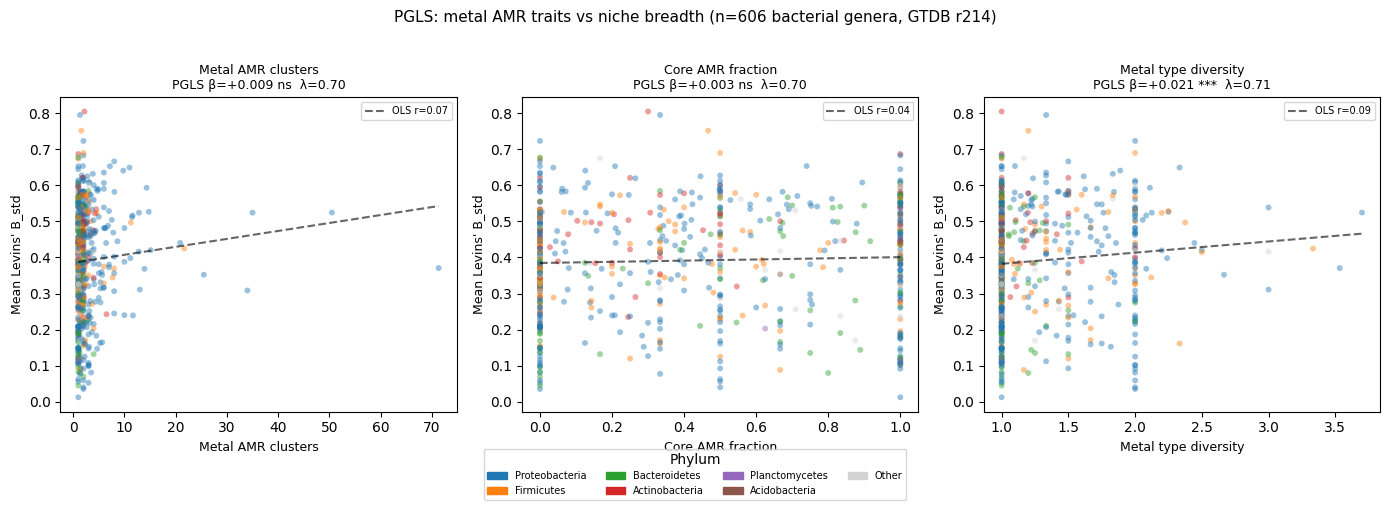

Saved figures/pgls_scatter.png


In [10]:
# ── 5b: Partial regression scatter plots ────────────────────────────────────
# One panel per predictor; response = Levins' B_std.
# Points coloured by phylum (top 6) to show phylogenetic spread.

pgls_df_plot = pd.read_csv(DATA / 'pgls_subset.csv')

top_phyla = pgls_df_plot['phylum'].value_counts().head(6).index.tolist()
palette = dict(zip(top_phyla, plt.cm.tab10.colors[:6]))
pgls_df_plot['phylum_col'] = pgls_df_plot['phylum'].apply(
    lambda p: palette.get(p, 'lightgray'))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, pred_raw, pred_z_col, pred_lbl in zip(
    axes, AMR_COLS,
    [c + '_z' for c in AMR_COLS],
    ['Metal AMR clusters', 'Core AMR fraction', 'Metal type diversity']
):
    ax.scatter(
        pgls_df_plot[pred_raw],
        pgls_df_plot['mean_levins_B_std'],
        c=pgls_df_plot['phylum_col'],
        alpha=0.45, s=18, linewidths=0
    )

    # OLS trendline for visual reference
    xv = pgls_df_plot[pred_raw].dropna()
    yv = pgls_df_plot.loc[xv.index, 'mean_levins_B_std']
    m, b_ols, r, p_ols, _ = sp_stats.linregress(xv, yv)
    xline = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xline, m * xline + b_ols, 'k--', lw=1.5, alpha=0.6, label=f'OLS r={r:.2f}')

    # Annotate with PGLS β from results
    pred_z_name = pred_raw + '_z'
    pgls_row = results[
        (results['response'] == 'mean_levins_B_std') &
        (results['predictor'] == pred_z_name)
    ]
    if len(pgls_row) > 0:
        row = pgls_row.iloc[0]
        sig_str = row['sig']
        lam_str = f"λ={row['lambda']:.2f}"
        ax.set_title(f"{pred_lbl}\nPGLS β={row['beta']:+.3f} {sig_str}  {lam_str}",
                     fontsize=9)
    else:
        ax.set_title(pred_lbl, fontsize=9)

    ax.set_xlabel(pred_lbl, fontsize=9)
    ax.set_ylabel("Mean Levins' B_std", fontsize=9)
    ax.legend(fontsize=7)

# Phylum legend
phylum_patches = [mpatches.Patch(color=c, label=p) for p, c in palette.items()]
phylum_patches.append(mpatches.Patch(color='lightgray', label='Other'))
fig.legend(handles=phylum_patches, title='Phylum', loc='lower center',
           ncol=4, fontsize=7, bbox_to_anchor=(0.5, -0.08))

plt.suptitle(
    "PGLS: metal AMR traits vs niche breadth (n=606 bacterial genera, GTDB r214)",
    y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'pgls_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pgls_scatter.png')

## 6. Summary

PGLS regression (ape::gls + corPagel, λ estimated jointly via ML, n = 606 bacterial genera).

### Results

| Response | Predictor (z-scored) | λ | β | p | Bonf. sig? |
|----------|---------------------|---|---|---|------------|
| Levins' B_std | AMR clusters | 0.700 | +0.010 | 0.090 | no |
| Levins' B_std | Core AMR fraction | 0.701 | +0.003 | 0.523 | no |
| Levins' B_std | Metal types | 0.708 | **+0.021** | **1.5×10⁻⁴** | **yes** |
| n_envs | AMR clusters | 0.847 | -0.071 | 0.290 | no |
| n_envs | Core AMR fraction | 0.839 | +0.142 | 0.038 | no |
| n_envs | Metal types | 0.848 | -0.007 | 0.923 | no |

Bonferroni threshold (6 simple models): p < 0.0083.

**Multi-predictor model** (Levins' B_std ~ all 3, λ = 0.706):

| Predictor | β | p |
|-----------|---|---|
| AMR clusters | -0.002 | 0.789 |
| Core AMR fraction | +0.006 | 0.288 |
| **Metal types** | **+0.023** | **0.0006** |

### Interpretation

**Metal type diversity is the only robust predictor of niche breadth** (survives Bonferroni
correction and remains significant in the multi-predictor model). The direction is **positive**:
genera that can resist a broader range of metals (more metal types) occupy broader ecological
niches. Genera with many AMR gene copies (high cluster count) or with constitutive core AMR
do not show the same effect once phylogeny is controlled.

This pattern supports the **co-evolution / metabolic versatility** hypothesis: bacteria that
have evolved to tolerate metal diversity (multi-contaminated soils, estuarine sediments) are
also ecologically versatile more broadly. Total AMR gene burden appears to be phylogenetically
structured but does not independently predict habitat range.

**λ in PGLS context**: The PGLS λ estimates (0.70 for niche breadth, 0.84 for n_envs) are
consistent with but slightly lower than the NB04 Pagel's λ estimates (0.787, 0.909). This
expected difference arises because the PGLS estimates λ jointly with the regression residuals
(which removes some systematic variance explained by the predictor).

### Technical note

`ape::corPagel` without a `form` argument matches data rows to tree tips by **position**,
not by species name. The data must be sorted to match `tree$tip.label` before calling `gls()`.
See `docs/pitfalls.md` for the fix. The earlier failed run (λ ≈ 0.14 for n_envs) was caused
by this misalignment.

### Next steps

- **NB06**: Synthesis figures — combine Pagel λ heatmap (NB04) with PGLS forest plot (NB05)
  into a single publication-quality multi-panel figure for the project REPORT.md.

In [11]:
# Print final results summary
results = pd.read_csv(DATA / 'pgls_results.csv')
results['predictor_label'] = results['predictor'].map(pred_labels).fillna(results['predictor'])
results['response_label']  = results['response'].map(resp_labels).fillna(results['response'])
results['sig'] = results['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print('=== PGLS results summary ===')
print(results[['response_label', 'predictor_label', 'n_taxa', 'lambda',
               'beta', 'SE', 'p_value', 'delta_AIC', 'sig']].to_string(index=False))

=== PGLS results summary ===
       response_label       predictor_label  n_taxa   lambda      beta       SE  p_value  delta_AIC sig
        Levins' B_std      AMR clusters (z)     606 0.699754  0.009455 0.005568 0.090004  -0.883092  ns
        Levins' B_std Core AMR fraction (z)     606 0.701235  0.003463 0.005419 0.522995   1.591297  ns
        Levins' B_std       Metal types (z)     606 0.707958  0.021459 0.005631 0.000153 -12.392537 ***
Environments detected      AMR clusters (z)     606 0.846895 -0.070902 0.066989 0.290292   0.877235  ns
Environments detected Core AMR fraction (z)     606 0.839236  0.142305 0.068599 0.038460  -2.264088   *
Environments detected       Metal types (z)     606 0.847473 -0.006847 0.070882 0.923079   1.990645  ns
